<a href="https://colab.research.google.com/github/rbryan2001/CSCI_591/blob/main/assignments/assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 -  Modeling data

## *Rebecca Bryan*
Netid: 790759512

Note: this assignment falls under collaboration Mode 2: Individual Assignment – Collaboration Permitted. Please refer to the syllabus on Canvas for additional information.

Instructions for all assignments can be found [here](https://github.com/lucywowen/csci547_ML/blob/main/assignments/_Assignment%20Instructions.ipynb) and in the course syllabus on canvas.

Total points in the assignment add up to 90; an additional 10 points are allocated to presentation quality.

#  Learning Objectives
The purpose of this assignment is to provide a deeper understanding into some of the recent concepts we've covered.  We'll work through a logistic regression analysis as well as apply some clustering technqiues using real brain data.  We'll also get those group projects started.  Please allow for enough time for this last section.  This will set you up for your group project analyses and hopefully get those wheels in motion!!

*Note: for all assignments, write out all equations and math using markdown and [LaTeX](https://tobi.oetiker.ch/lshort/lshort.pdf). For this assignment show ALL math work*

**ANSWER**

# Logistic regression

## 1
**[30 points]**


**Data**. The data for this problem can be found in the `data` subfolder in the `assignments` folder on [github](https://github.com/lucywowen/csci591_CCN). The filename is `stroke.csv`.

A stroke occurs when the blood flow to a part of the brain is reduced or restricted. Due to this brain cells start to die, in that part of the brain, at a very fast rate due to a lack of oxygen and nutrients. There are two types of brain strokes: (a) Ischemic stroke and (b) Haemorrhagic stroke of which ischemic stroke is more likely to occur. The rupture or blockage prevents blood and oxygen from reaching the brain’s tissues.
 Here we have used 8 input parameters like gender, age, various diseases, and smoking status in this dataset on brain stroke detection from Kaggle.
 The following information is provided about the patient:

    
|field    |description|
|:-----   |:-----|
|id       |unique identifier|
|gender   |'Male', 'Female', or 'Other'|
|age   |age of patient|
|hypertension    |0 if patient doesn't have hypertension; 1 if patient has hypertension|
|heart_disease      |0 if patient doesn't have heart disease; 1 if patient has heart disease|
|ever_married     |'No', 'Yes'|
|work_type |'children', 'Govt_jov', 'Never_worked', 'Private', 'Self-employed' |
|Residence_type   |'Rural', 'Urban' |
|avg_glucose_level |average glucose level of the patient|
|bmi |body mass index of the patient|
|smoking_status |'formerly smoked', 'never smoked', 'smokes', 'Unknown'|
|stroke |0 if patient has not had a stroke; 1 if patient has had a stroke|


**Your objective**. For this dataset, your goal is to create a logistic regression model that predicts which patients will more likely have a stroke.  Let's break it down:

a. First load in the data. You've already explored this data a bit in the previous assignment, but it would be good to get know the data again.  Start by exploring some distributions of stroke occurrences based on categorical and numerical features using histograms.  

b. What do you see about the distribution of the number of patients who have had a stroke compared to the number of patients who have not had a stroke?  Is this a balanced dataset?

c. Data transformations: Since the dataset is a mixture of numeric and categorical data, use one-hot encoding to transform the categorical data. Then make sure to rescale your numerical data and either drop or impute missing values.

d. Calculate correlations and plot some heatmaps to see how these variables relate to one another.

e. Use `Scikit-Learn` to perform logistic regression and show your results using `classification_report`.  Interpret these results.  What's the overall accuracy?  But what is the precision and recall values for stroke and no stroke?  What does this mean in terms of the imbalanced data?

f. Extra credit (5 points): Try to resample the data to address the imbalance and re-run logistic regression.  How does this change your interpretation of the classification results?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [3]:
file_path = "/stroke.csv"
df = pd.read_csv(file_path)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


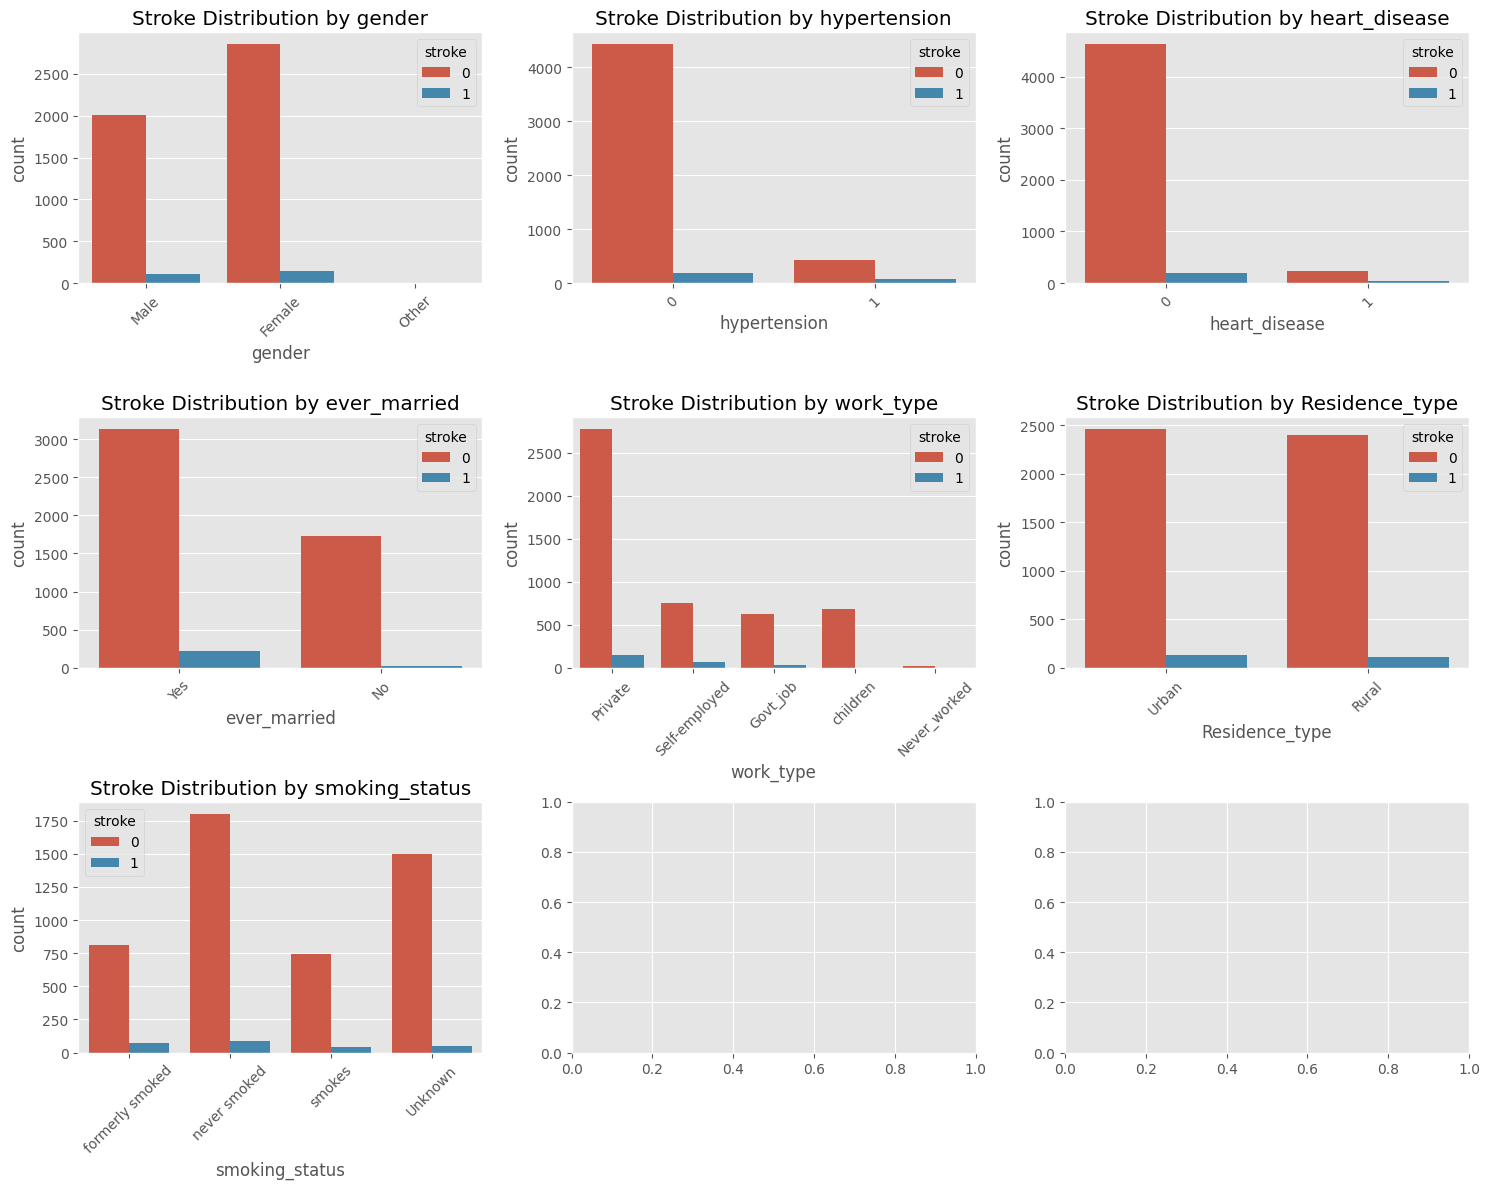

In [4]:
plt.style.use("ggplot")

categorical_features = ["gender", "hypertension", "heart_disease", "ever_married", "work_type", "Residence_type", "smoking_status"]
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    if i < len(categorical_features):
        sns.countplot(data=df, x=feature, hue="stroke", ax=axes[i])
        axes[i].set_title(f"Stroke Distribution by {feature}")
        axes[i].tick_params(axis='x', rotation=45)  # Rotate labels

plt.tight_layout()
plt.show()

It's hard to notice anything about these distributions because the variables are not scaled. For example, it looks like more females had strokes than males, however in general, there seem to be more females than males in the dataset as a whole. Another good example is the distribution under the variable heart_disease. It is known that having heart disease makes someone more likely to have a stroke, however looking at the distribution, it looks like more people *without* heart disease had a stroke, which is technically true, however far more people in the dataset don't have heart disease, so of course there will be more without heart disease who had a stroke, simply because there's more people. In order to truly see any patterns, the data needs to be scaled.

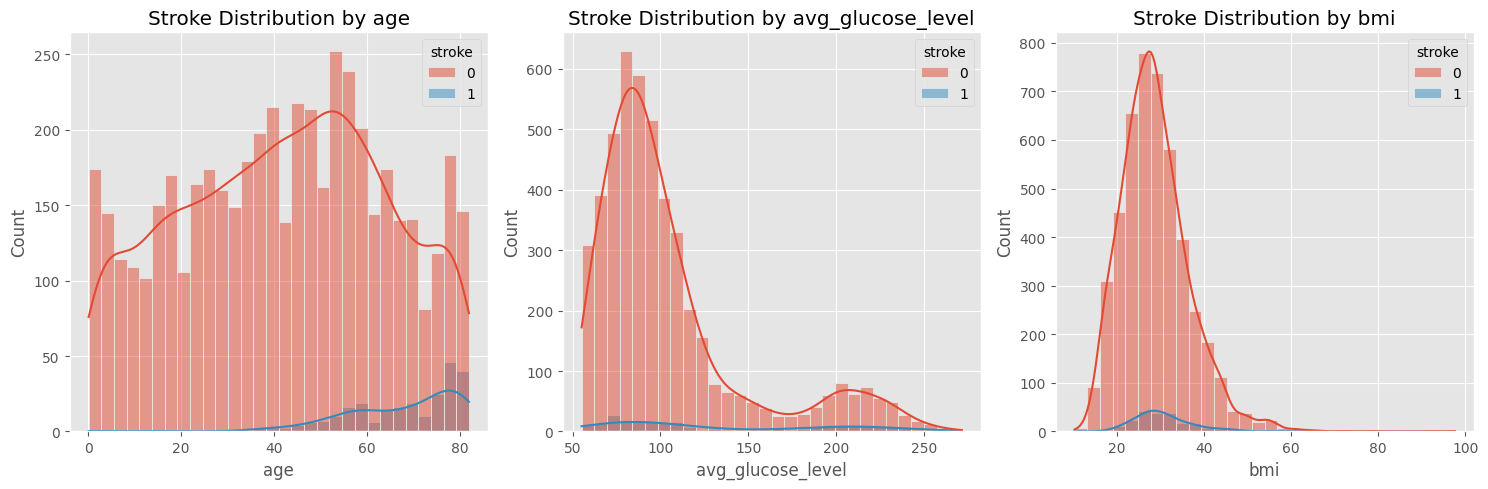

In [5]:
# Plot distribution of stroke occurrences across numerical features
numerical_features = ["age", "avg_glucose_level", "bmi"]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for i, feature in enumerate(numerical_features):
    sns.histplot(df, x=feature, hue="stroke", kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Stroke Distribution by {feature}")

plt.tight_layout()
plt.show()

These plots follow the same issue as above, however, there are a few interesting things to note that are more clear despite the lack of scaling. There appear to be more instances of stroke in people ages 60 and above, which is consistent with what we know about who is at risk for stroke. There appears to be two areas of hightened numbers of stroke with avg_glucose_level: those with glucose level between 50 and 100 (aka, low glucose) and those with glucose level between 175 and 250 (aka, high glucose).

**b.)** There are far more patients who have not had a stroke than patients who have had a stroke. This is not a balanced data set

In [6]:
# separate features and target variable
X = df.drop(columns=['stroke','id'])
y = df['stroke']

# define categorical and numerical features
cat_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
num_features = ["age", "avg_glucose_level", "bmi"]

# handle missing values for numerical data (impute with mean) and scale
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# One-hot encode categorical features
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformations
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Apply transformations to dataset and convert to dataframe
X_transformed = preprocessor.fit_transform(X)
encoded_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features)
new_feature_names = num_features + list(encoded_feature_names)
X_transformed_df = pd.DataFrame(X_transformed, columns=new_feature_names)
X_transformed_df.head()

,age,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.051434,2.706375,1.001234e+00,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.786070,2.121559,4.615554e-16,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.626390,-0.005028,4.685773e-01,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.255342,1.437358,7.154182e-01,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.582163,1.501184,-6.357112e-01,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


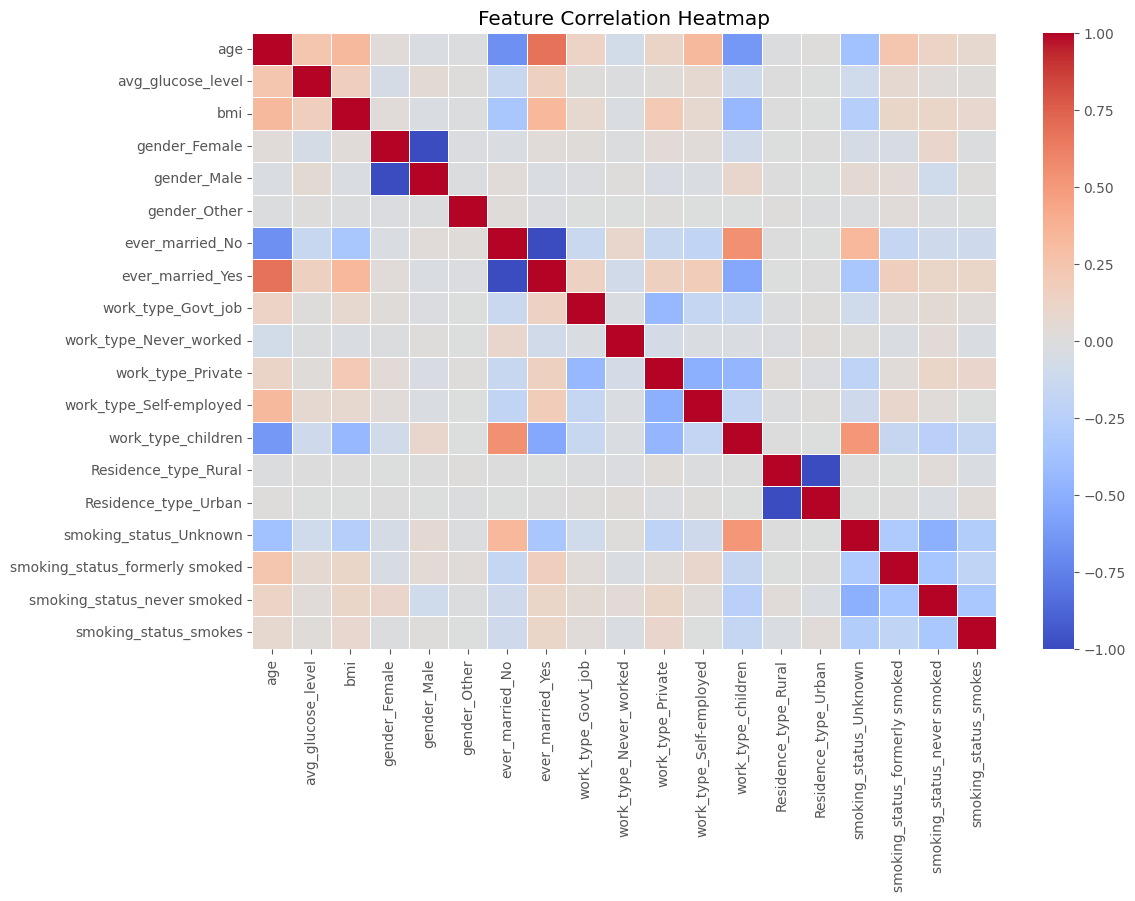

In [7]:
correlation_matrix = X_transformed_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

There are a few features that appear to have moderate correlation. Age appears to have the most correlation with other features. It is worth noting that gender (male or female), ever_married (yes or no), and residence type (urban or rural) are mutually exclusive and have a -1 correlation.

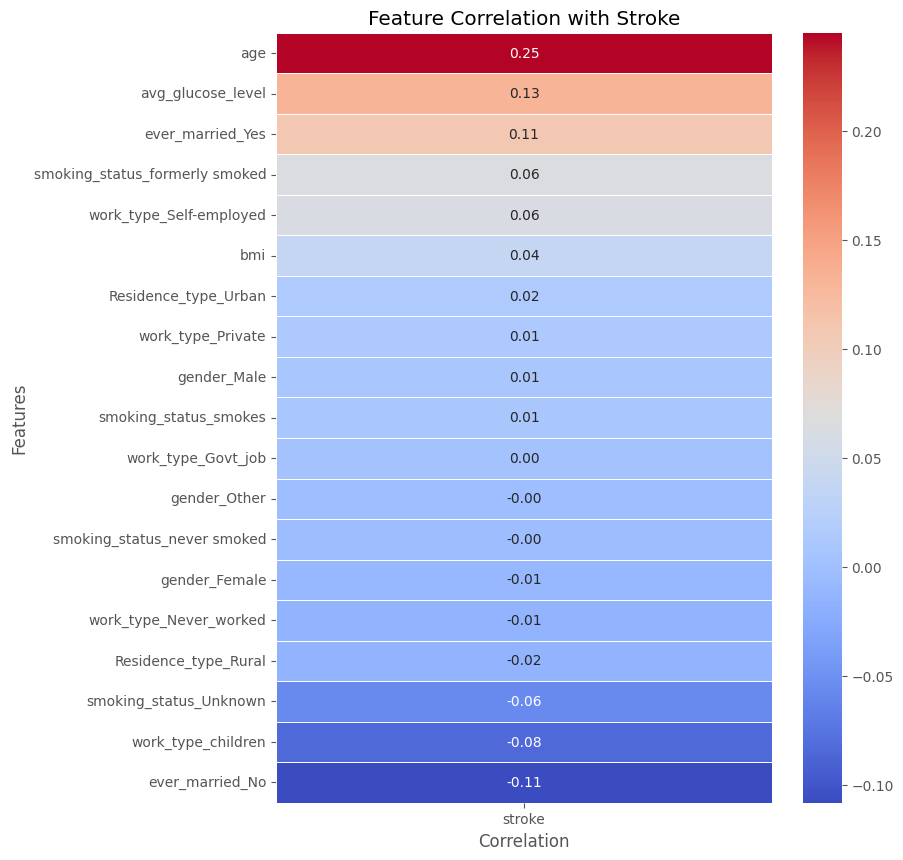

In [8]:
# Add stroke to dataset to calculate correlation between features and stroke
transformed_df = X_transformed_df.copy()
transformed_df["stroke"] = y.values

# Compute the correlation matrix including stroke
full_correlation_matrix = transformed_df.corr()

# Extract correlations of all features with stroke, excluding stroke itself
stroke_correlation = full_correlation_matrix["stroke"].drop("stroke").sort_values(ascending=False)

# Plot heatmap for stroke correlation with each feature
plt.figure(figsize=(8, 10))
sns.heatmap(stroke_correlation.to_frame(), annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Feature Correlation with Stroke")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

There is a moderate correlation between age and stroke.

There is a weak positive correlation between stroke and avg_glucose_level,ever_married_yes, smoking_status_formerly_smoked, work_type_self_employed, and bmi.

There is a weak negative correlation between stroke and smoking_status_unknown, work_type_children, and ever_married_no.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
# Split dataset into training and test sets (80-20 split, stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(X_transformed_df, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train logistic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predict on test data
y_pred = log_reg.predict(X_test)

# Generate classification report with zero_division=0 to handle undefined precision
classification_results = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

# Convert classification report to DataFrame for better readability
classification_df = pd.DataFrame(classification_results).transpose()

classification_df

,precision,recall,f1-score,support
0,0.951076,1.000000,0.974925,972.000000
1,0.000000,0.000000,0.000000,50.000000
accuracy,0.951076,0.951076,0.951076,0.951076
macro avg,0.475538,0.500000,0.487462,1022.000000
weighted avg,0.904546,0.951076,0.927228,1022.000000


In [11]:
# Compute and display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[972,   0],
       [ 50,   0]])

The overall accuracy for this model is 95.1%, however this model does not predict any stroke cases. Precision for no_stroke is 0.951 and recall is 1.00, so the model correctly identified all non-stroke cases. However, the precion and recall for stroke is 0.00, as the model did not predict any stroke cases. Because there are so few stroke cases in the data set (i.e. the data set is imbalanced) the model ignores it and prioritizes accuracy over recall, which is not efficient for predicting rare events. This is a common pitfall for imbalanced data sets and because of this, this model is unusable for real-world applications.

In [12]:
from sklearn.utils import resample

In [13]:
# Reset index to avoid duplicate index issues
X_trans_df_reset = X_transformed_df.reset_index(drop=True)
y_reset = y.reset_index(drop=True)

# Combine X and y into a single DataFrame for resampling
data_resample = pd.concat([X_trans_df_reset, y_reset], axis=1)

# Separate majority and minority class
stroke_no = data_resample[data_resample["stroke"] == 0] # majority stroke=no
stroke_yes = data_resample[data_resample["stroke"] == 1] # minority stroke=yes

# Oversample the minority class (stroke=yes)
stroke_yes_oversampled = resample(stroke_yes,
                                       replace=True,
                                       n_samples=len(stroke_no),
                                       random_state=42)

# Combine majority class with oversampled minority class
data_balanced = pd.concat([stroke_no, stroke_yes_oversampled])

# Shuffle dataset after resampling
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Separate features and target variable again
X_balanced = data_balanced.drop(columns=["stroke"])
y_balanced = data_balanced["stroke"]

# Split the balanced dataset into training and test sets
X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

# Train logistic regression on the balanced dataset
log_reg_balanced = LogisticRegression(max_iter=1000)
log_reg_balanced.fit(X_train_balanced, y_train_balanced)

# Predict on test data
y_pred_balanced = log_reg_balanced.predict(X_test_balanced)

# Generate classification report
results_balanced = classification_report(y_test_balanced, y_pred_balanced, output_dict=True)

# Convert classification report to DataFrame for better readability
results_df_balanced = pd.DataFrame(results_balanced).transpose()

results_df_balanced

,precision,recall,f1-score,support
0,0.810185,0.719424,0.762112,973.000000
1,0.747456,0.831276,0.787141,972.000000
accuracy,0.775321,0.775321,0.775321,0.775321
macro avg,0.778821,0.775350,0.774626,1945.000000
weighted avg,0.778837,0.775321,0.774620,1945.000000


In [14]:
# balanced confidence matrix
conf_mat_balanced = confusion_matrix(y_test_balanced, y_pred_balanced)
conf_mat_balanced

array([[700, 273],
       [164, 808]])

Artificially balancing the data set by oversampling the cases where stroke=1 leads to a model with less overall accuracy, however it is more applicable to real world data. The new overall accuracy is 0.775. While precision for no_stroke is significantly lower (0.81 compared to 0.95), precision for stroke cases is now much higher at 0.747 compared to 0 like before. This means the model is not ignoring the stroke classification, and is more likely to accurately predict the presence of a stroke.

# PCA and KMeans
## 2
**[25 points]**

**Data**. The data for this problem can be found in the `data` subfolder in the `assignments` folder on [github](https://github.com/lucywowen/csci591_CCN). The filename is `wave_form.csv`.

Epilepsy is a form of brain disorder in which an excess of synchronous electrical brain activity leads to seizures which can range from having no outward symptom at all to jerking movements (tonic-clonic seizure) and loss of awareness (absence seizure). For some epilepsy patients surgical removal of the effected brain tissue can be an effective treatment. But before a surgery can be performed the diseased brain tissue needs to be precisely localized. To find this seizure focus, recording electrodes are inserted into the patients brain with which the neural activity can be monitored in real time. The electrophysiological data you'll be working with has been acquired from a human epilepsy patient and has already been processed to extract spike events.

Spike events reflect the activity of individual neurons and therefore can give important insights into the nature of the disease. However, a single electrode will typically pick up signals from more than one neuron at a time. While this might not be an issue for locating the seizure focus, research questions related to the mechanisms behind epileptic seizures often require a more detailed understanding of which neuron was active at what time. So how can we figure out the how many neurons were contributing to our signal and when each of them was active?

To do this we will use an unsupervised clustering algorithm (K-means clustering) to sort our spike data. However, the first thing we need to do is decide what features of our spike wave forms we want to feed into our algorithm.  To do this, we will apply principal component analysis (PCA) and use the principal components as features. While before each spike wave form was represented by 9 samples (in part a) the dimensionality is now reduced to only three features which allow us to assign each spike to a cluster.

All that's left is deciding how many clusters we expect to find.  From literature review, we expect not to find more than two or three separable clusters from a single electrode recording. However, we'll also run the K-means function several times on our data and increase the number of clusters with every run.  That way we can decide based on the 'Elbow method'. Ready? Let's go...


**Your objective**. For this dataset, you'll perform an analysis to attribute spikes to neurons.  Let's break it down:

a. Load in the data and plot the wave forms on one plot.  The data are arranged as #spikes (2401) by #samples (100).  To do this randomly sample 100 spikes and plot those wave forms on one plot.  I have some code below to help get started with this.

b. Principal component analysis (PCA) is a dimensionality reduction method which requires normalized data.  Use `Scikit Learn` for both the normalization (`MinMaxScaler()`) and `PCA` (you can use `n_components=12`).

c. Run `KMeans` from `Scikit Learn` on your reduced data several times using more and more clusters (`n_clusters=1` to `n_clusters=8`).  Plot the `.inertia_` values for each corresponding cluster.  Do you see an elbow?  Where do you think it is?

d. Plot the wave forms for `n_clusters=3`.

e. What do these wave forms look like?  Have you seen other plots with this shape before?

**ANSWER**

In [15]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

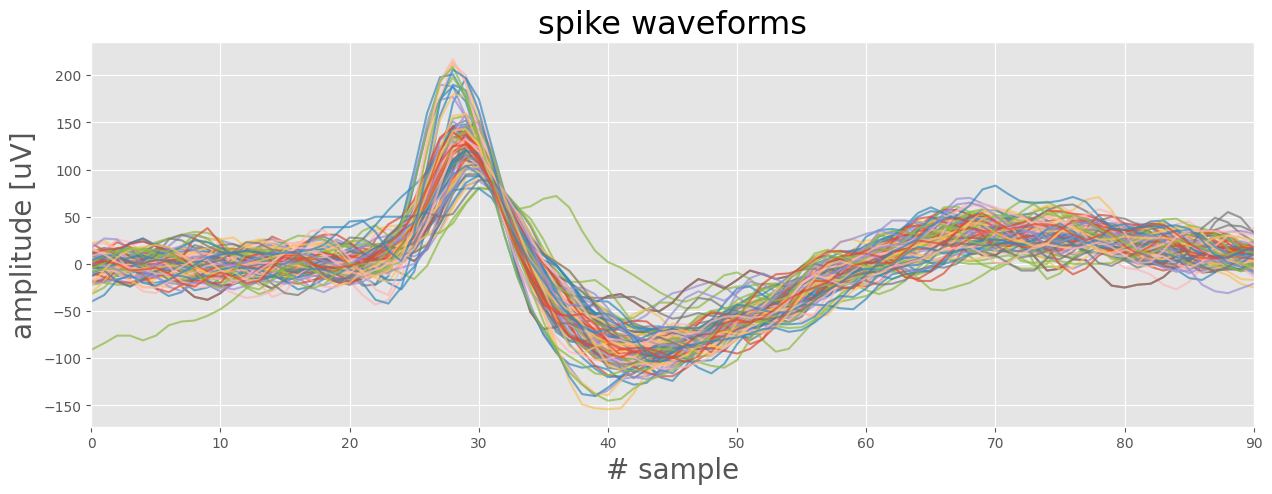

In [16]:
file_path = "/wave_form.csv"
waveform_data = pd.read_csv(file_path, header=None)
wave_form = waveform_data.to_numpy()
np.random.seed(10)
fig, ax = plt.subplots(figsize=(15, 5))

for i in range(100):
    spike = np.random.randint(0, wave_form.shape[0])
    ax.plot(wave_form[spike], alpha=0.7)

ax.set_xlim([0, 90])
ax.set_xlabel('# sample', fontsize=20)
ax.set_ylabel('amplitude [uV]', fontsize=20)
ax.set_title('spike waveforms', fontsize=23)
plt.show()

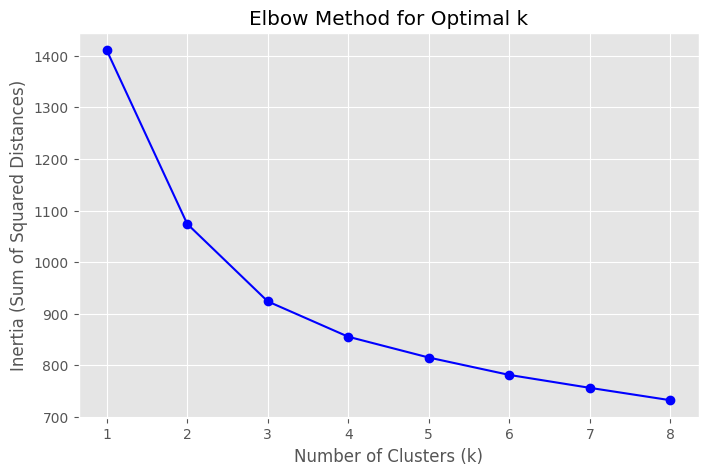

In [17]:
scaler = MinMaxScaler()
wave_form_scaled = scaler.fit_transform(wave_form)

# Apply PCA with n_components=12
pca = PCA(n_components=12)
wave_form_pca = pca.fit_transform(wave_form_scaled)

# Run KMeans for n_clusters from 1 to 8 and store inertia values
inertia_values = []
cluster_range = range(1, 9)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(wave_form_pca)
    inertia_values.append(kmeans.inertia_)

# Plot the inertia values to identify the elbow point
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia_values, marker='o', linestyle='-', color='b')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.title("Elbow Method for Optimal k")
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

Inertia appears to stop significantly decreasing at k=3.

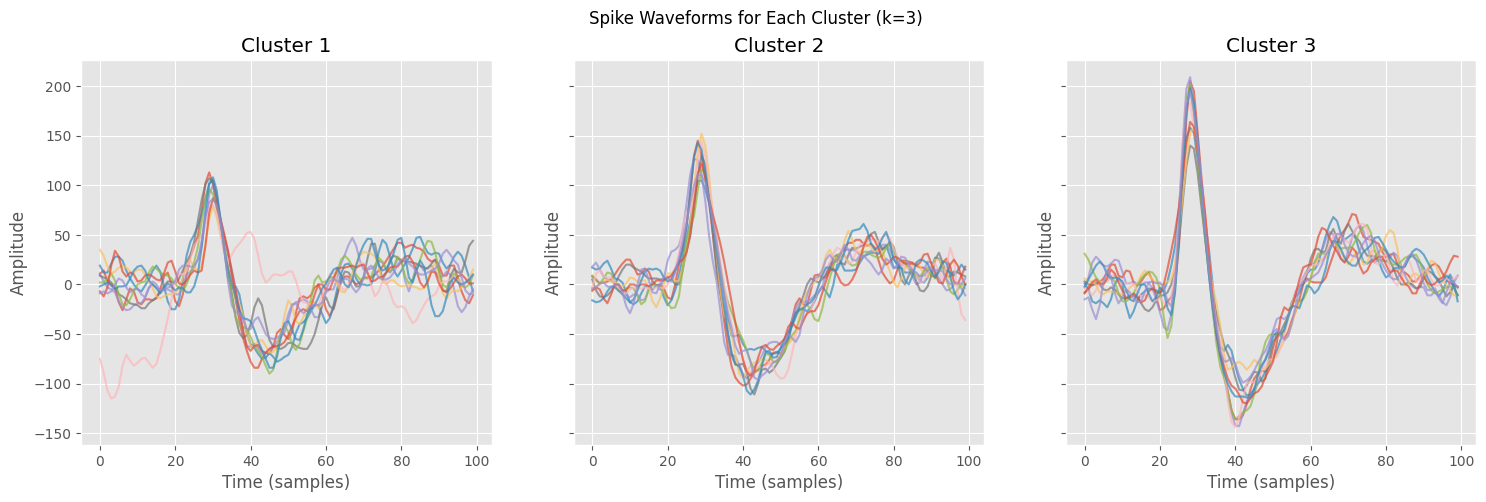

In [18]:
# Run K-Means clustering with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(wave_form_pca)

# Add cluster labels to the original waveforms for plotting
wave_form_clustered = pd.DataFrame(wave_form)
wave_form_clustered["cluster"] = cluster_labels

# Plot waveforms for each cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for cluster in range(3):
    ax = axes[cluster]
    cluster_samples = wave_form_clustered[wave_form_clustered["cluster"] == cluster].sample(n=10, random_state=42)

    for i in range(10):
        ax.plot(cluster_samples.iloc[i, :-1], alpha=0.7)  # Exclude cluster label from plotting

    ax.set_title(f"Cluster {cluster + 1}")
    ax.set_xlabel("Time (samples)")
    ax.set_ylabel("Amplitude")

plt.suptitle("Spike Waveforms for Each Cluster (k=3)")
plt.show()

Each of the three spikes appear to have different amplitudes. Cluster 1 has an amplitude of around 100 $\mu$V, Cluster 2 has an amplitude of around 150 $\mu$V, and Cluster 3 has an amplitude of around 200 $\mu$V. These spikes looks like the action potential plots we've looked at in class. The distinct clusters tell us we likely have at least 3 different neurons contributing to the signal. There does appear to be one waveform (the pink color in Cluster 1) that doesn't quite match up with any of the other waves, and I would be curious to explore that further.

# Project data analysis

## 3
**[35 points]**

**Data**. The data you'll use for this section will be related to your project (either the data you're working on with your group or a different dataset related to your question).  

**Objective**. For this you'll use a machine learning model (supervised or unsupervised... preferablly one we've discussed in class) to analyze your data. You can work with your group on this, but you should each submit a *different* analysis.  Here's some expectations:

a. Exploration and visualization: Do some data exploration with at least 3 plots.

b. Preprocessing: Perform any necessary data transformations and handle any missing data. Explain what you did!

c. Modeling: Pick a model and analyze your data.  Explain your motivation behind this particular model.  Do forget to split your data into training and testing sets!

d. Evaluation: Evaluate your model.  The metrics you use should be consistent with the model you chose.  Explain your results.

e. Insights: Provide any insights this modeling exercise gave you and how will it inform your future work on this project?  Please write out your next steps for analyses.  

**ANSWER**

Our project involves looking at methods for automated lesion segmentation using MRI images. The goal is to compare error rates between student drawn and automated segmentation masks compared to professional drawn lesion masks.

We have 5 example MRIs with separate hand-drawn lesion masks that I will start my data exploration with.

In [19]:
import nibabel as nib

Let's first upload one MRI scan and lesion mask, and plot them side by side. The lesion mask looks like this:

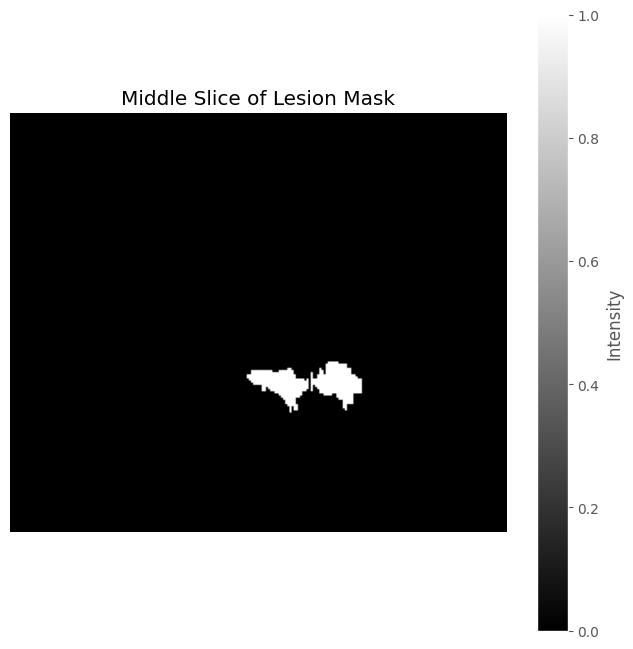

In [20]:
nii_file_path = "/Example #2 Lesion Mask.nii"
nii_img = nib.load(nii_file_path)
nii_data = nii_img.get_fdata()

# Display a middle slice of the 3D volume
middle_slice = nii_data.shape[2] // 2  # Get the middle slice along the third axis

plt.figure(figsize=(8, 8))
plt.imshow(nii_data[:, :, middle_slice], cmap="gray")
plt.colorbar(label="Intensity")
plt.title("Middle Slice of Lesion Mask")
plt.axis("off")
plt.show()

So it will have to be overlayed over the orignial MRI scan.

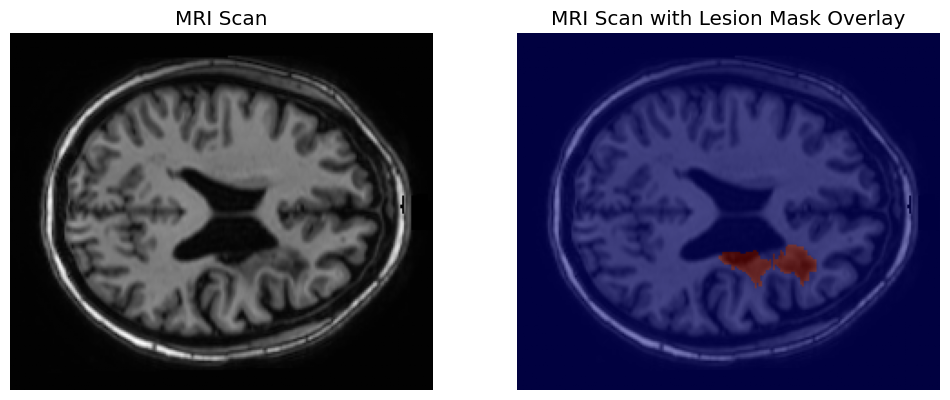

In [21]:
mri2_file_path = "/Example #2 Scan.nii"
mask2_file_path = "/Example #2 Lesion Mask.nii"
ex2_scan = nib.load(mri2_file_path).get_fdata()
ex2_mask = nib.load(mask2_file_path).get_fdata()

# Ensure both images have the same shape
if ex2_scan.shape != ex2_mask.shape:
    raise ValueError("MRI scan and lesion mask have different dimensions!")

# Select the middle slice
middle_slice = ex2_scan.shape[2] // 2

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot MRI scan
axes[0].imshow(ex2_scan[:, :, middle_slice], cmap="gray")
axes[0].set_title("MRI Scan")
axes[0].axis("off")

# Overlay lesion mask on MRI scan
axes[1].imshow(ex2_scan[:, :, middle_slice], cmap="gray")
axes[1].imshow(ex2_mask[:, :, middle_slice], cmap="jet", alpha=0.5)  # Overlay mask with transparency
axes[1].set_title("MRI Scan with Lesion Mask Overlay")
axes[1].axis("off")

# Show the plots
plt.show()

Now let's look at all five scans.

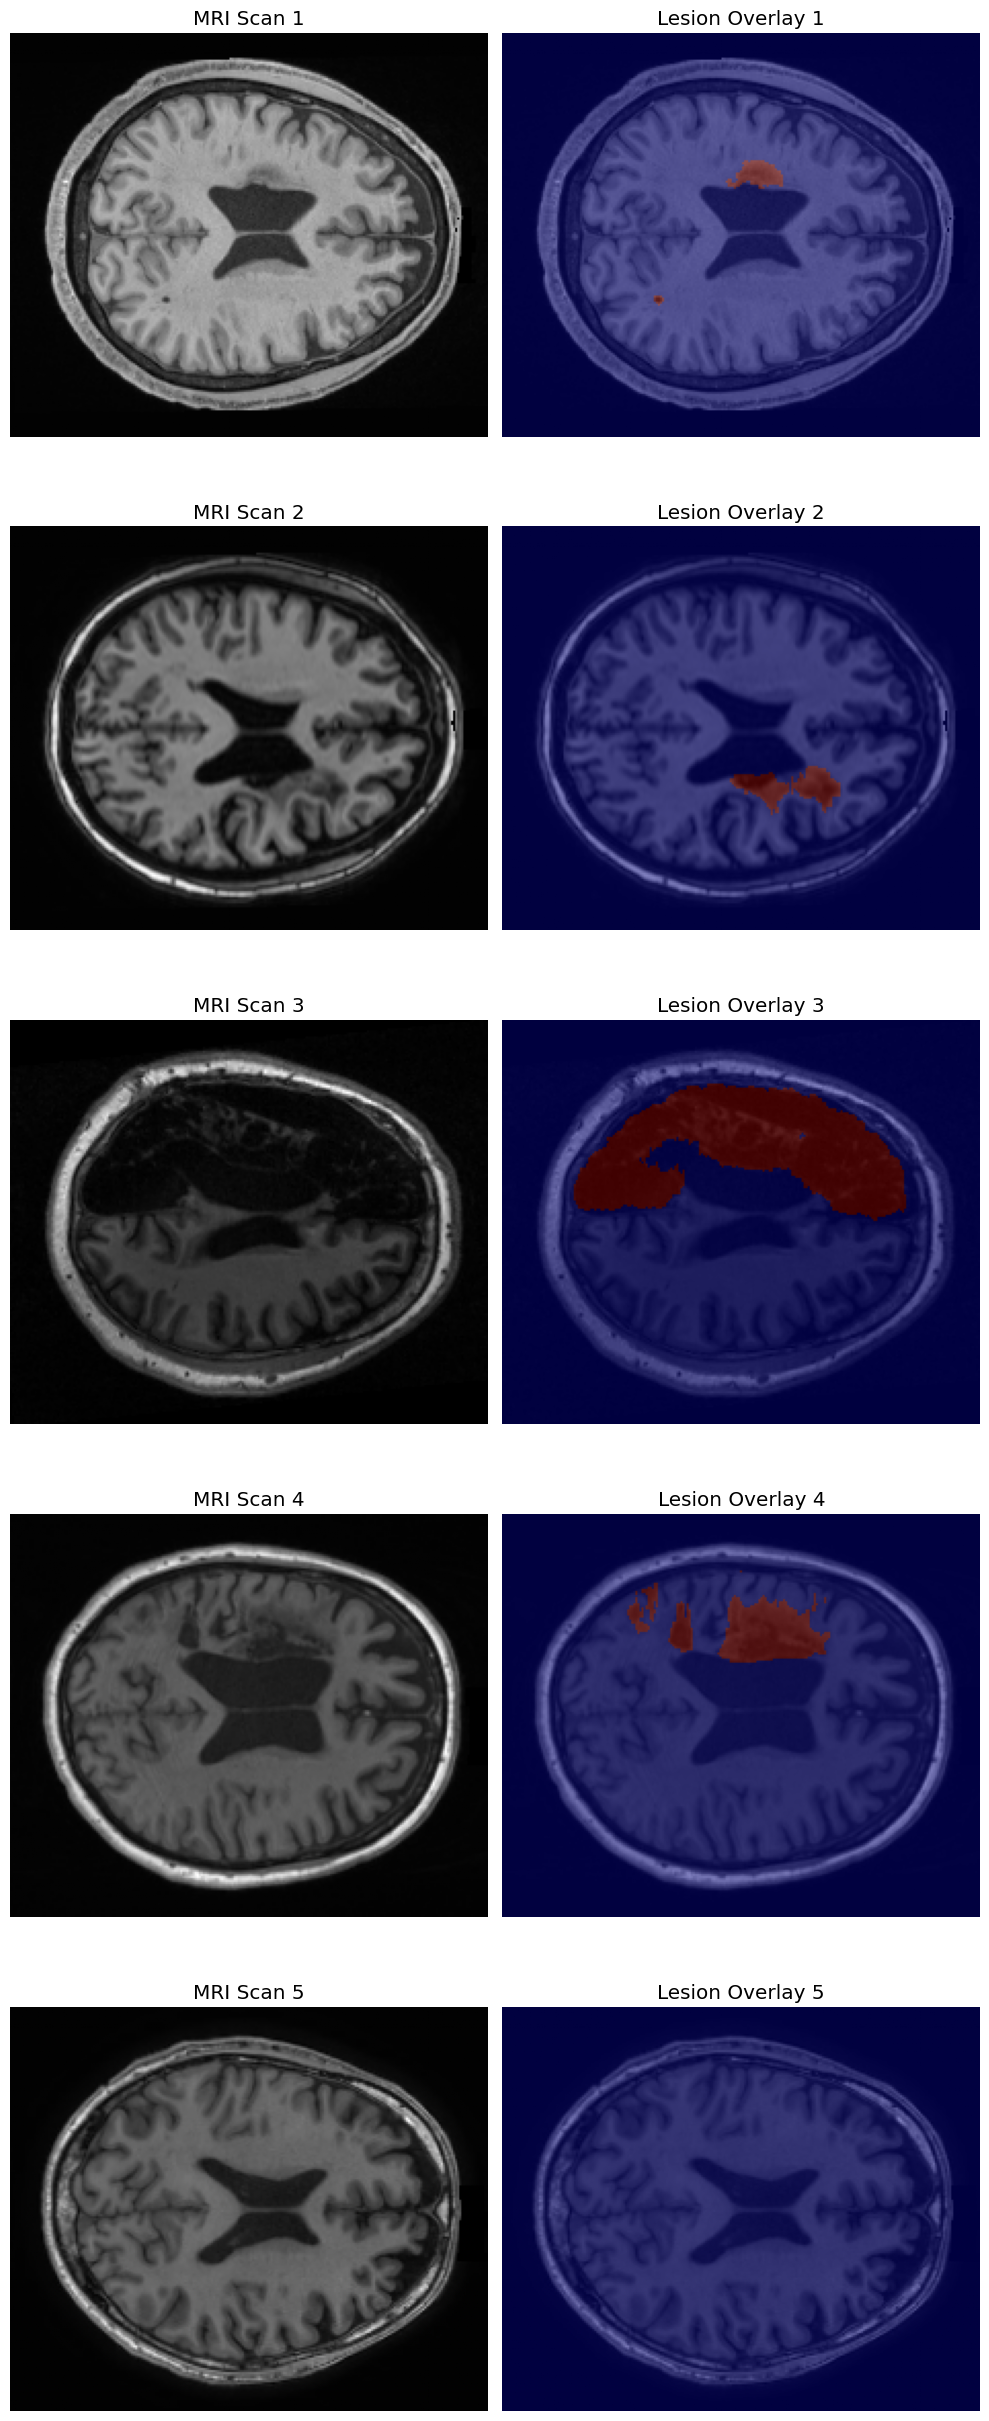

In [22]:
# Define file paths for the five examples
file_paths = [
    ("/Example #1 Scan.nii", "/Example #1 Lesion Mask.nii"),
    ("/Example #2 Scan.nii", "/Example #2 Lesion Mask.nii"),
    ("/Example #3 Scan.nii", "/Example #3 Lesion Mask.nii"),
    ("/Example #4 Scan.nii", "/Example #4 Lesion Mask.nii"),
    ("/Example #5 Scan.nii", "/Example #5 Lesion Mask.nii"),
]

# Create figure for multiple subplots (5 rows, 2 columns)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 25))

# Loop through each example and plot
for i, (mri_filename, mask_filename) in enumerate(file_paths):
    # Load MRI scan and lesion mask
    mri_data = nib.load(mri_filename).get_fdata()
    mask_data = nib.load(mask_filename).get_fdata()

    # Ensure both images have the same shape
    if mri_data.shape != mask_data.shape:
        raise ValueError(f"Shape mismatch: {mri_filename} and {mask_filename}")

    # Select the middle slice
    middle_slice = mri_data.shape[2] // 2

    # Plot MRI scan
    axes[i, 0].imshow(mri_data[:, :, middle_slice], cmap="gray")
    axes[i, 0].set_title(f"MRI Scan {i+1}")
    axes[i, 0].axis("off")

    # Plot MRI scan with lesion mask overlay
    axes[i, 1].imshow(mri_data[:, :, middle_slice], cmap="gray")
    axes[i, 1].imshow(mask_data[:, :, middle_slice], cmap="jet", alpha=0.5)
    axes[i, 1].set_title(f"Lesion Overlay {i+1}")
    axes[i, 1].axis("off")

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

Since we are most likely going to be using U-Net for our project, I am going to start with that.

In [44]:
import cv2
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Input, concatenate, BatchNormalization

In [42]:
# Define file paths for the five examples
train_paths = [
    ("/Example #1 Scan.nii", "/Example #1 Lesion Mask.nii"),
    ("/Example #2 Scan.nii", "/Example #2 Lesion Mask.nii"),
    ("/Example #3 Scan.nii", "/Example #3 Lesion Mask.nii")
]

test_paths = [
    ("/Example #4 Scan.nii", "/Example #4 Lesion Mask.nii"),
    ("/Example #5 Scan.nii", "/Example #5 Lesion Mask.nii"),
]

# Resize images and normalize
def preprocess_image(img, target_size=(256, 256)):
    img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_NEAREST)
    img_resized = img_resized / np.max(img_resized)  # Normalize to [0,1]
    return img_resized

# Load and preprocess training images
train_images, train_masks = [], []
for mri_file, mask_file in train_paths:
    mri_img = nib.load(mri_file).get_fdata()
    mask_img = nib.load(mask_file).get_fdata()

    middle_slice = mri_img.shape[2] // 2
    train_images.append(np.expand_dims(preprocess_image(mri_img[:, :, middle_slice]), axis=(0, -1)))
    train_masks.append(np.expand_dims(preprocess_image(mask_img[:, :, middle_slice]), axis=(0, -1)))

train_images = np.concatenate(train_images, axis=0)  # Shape: (3, 256, 256, 1)
train_masks = np.concatenate(train_masks, axis=0)    # Shape: (3, 256, 256, 1)

# Load and preprocess test images
test_images, test_masks = [], []
for mri_file, mask_file in test_paths:
    mri_img = nib.load(mri_file).get_fdata()
    mask_img = nib.load(mask_file).get_fdata()

    middle_slice = mri_img.shape[2] // 2
    test_images.append(np.expand_dims(preprocess_image(mri_img[:, :, middle_slice]), axis=(0, -1)))
    test_masks.append(np.expand_dims(preprocess_image(mask_img[:, :, middle_slice]), axis=(0, -1)))

test_images = np.concatenate(test_images, axis=0)  # Shape: (2, 256, 256, 1)
test_masks = np.concatenate(test_masks, axis=0)    # Shape: (2, 256, 256, 1)

<ipython-input-42-d205d7f2f534>:16: RuntimeWarning: invalid value encountered in divide
  img_resized = img_resized / np.max(img_resized)  # Normalize to [0,1]


In [45]:
def unet_model(input_shape=(256, 256, 1)):
    inputs = Input(input_shape)

    # Encoder
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = BatchNormalization()(conv1)
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(conv1)
    conv1 = BatchNormalization()(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = BatchNormalization()(conv2)
    conv2 = Conv2D(128, 3, activation='relu', padding='same')(conv2)
    conv2 = BatchNormalization()(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = BatchNormalization()(conv3)
    conv3 = Conv2D(256, 3, activation='relu', padding='same')(conv3)
    conv3 = BatchNormalization()(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    # Bottleneck
    conv4 = Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = BatchNormalization()(conv4)
    conv4 = Conv2D(512, 3, activation='relu', padding='same')(conv4)
    conv4 = BatchNormalization()(conv4)

    # Decoder
    up1 = UpSampling2D(size=(2, 2))(conv4)
    up1 = concatenate([up1, conv3])
    conv5 = Conv2D(256, 3, activation='relu', padding='same')(up1)
    conv5 = BatchNormalization()(conv5)
    conv5 = Conv2D(256, 3, activation='relu', padding='same')(conv5)
    conv5 = BatchNormalization()(conv5)

    up2 = UpSampling2D(size=(2, 2))(conv5)
    up2 = concatenate([up2, conv2])
    conv6 = Conv2D(128, 3, activation='relu', padding='same')(up2)
    conv6 = BatchNormalization()(conv6)
    conv6 = Conv2D(128, 3, activation='relu', padding='same')(conv6)
    conv6 = BatchNormalization()(conv6)

    up3 = UpSampling2D(size=(2, 2))(conv6)
    up3 = concatenate([up3, conv1])
    conv7 = Conv2D(64, 3, activation='relu', padding='same')(up3)
    conv7 = BatchNormalization()(conv7)
    conv7 = Conv2D(64, 3, activation='relu', padding='same')(conv7)
    conv7 = BatchNormalization()(conv7)

    outputs = Conv2D(1, 1, activation='sigmoid')(conv7)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Create and summarize the U-Net model
unet = unet_model()
unet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256, 256, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_15 (Conv2D)        │ (None, 256, 256, 64)   │            640 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 64)   │            256 │ conv2d_15[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 256, 256, 64)   │         36,928 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 256, 256, 64)   │            256 │ conv2d_16[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 128, 128, 64)   │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_17 (Conv2D)        │ (None, 128, 128, 128)  │         73,856 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 128, 128, 128)  │            512 │ conv2d_17[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_18 (Conv2D)        │ (None, 128, 128, 128)  │        147,584 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 128, 128, 128)  │            512 │ conv2d_18[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 64, 64, 128)    │              0 │ batch_normalization_3… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 64, 64, 256)    │        295,168 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 64, 64, 256)    │          1,024 │ conv2d_19[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_20 (Conv2D)        │ (None, 64, 64, 256)    │        590,080 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 64, 64, 256)    │          1,024 │ conv2d_20[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 7,793,025 (29.73 MB)

 Trainable params: 7,787,393 (29.71 MB)

 Non-trainable params: 5,632 (22.00 KB)

In [46]:
# Train U-Net
history = unet.fit(train_images, train_masks, epochs=20, batch_size=1, verbose=1)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 7s/step - accuracy: 0.5187 - loss: 0.9620
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 7s/step - accuracy: 0.5078 - loss: 0.7828
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.5655 - loss: 0.7260
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 8s/step - accuracy: 0.6392 - loss: 0.6557
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.7791 - loss: 0.5743
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.8232 - loss: 0.5532
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.8441 - loss: 0.5672
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.8770 - loss: 0.5609
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.8548 - loss: 0.5416
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.9040 - loss: 0.5256
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.9322 - loss: 0.4249
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.9453 - loss: 0.4885
Epoch 13/20
3

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


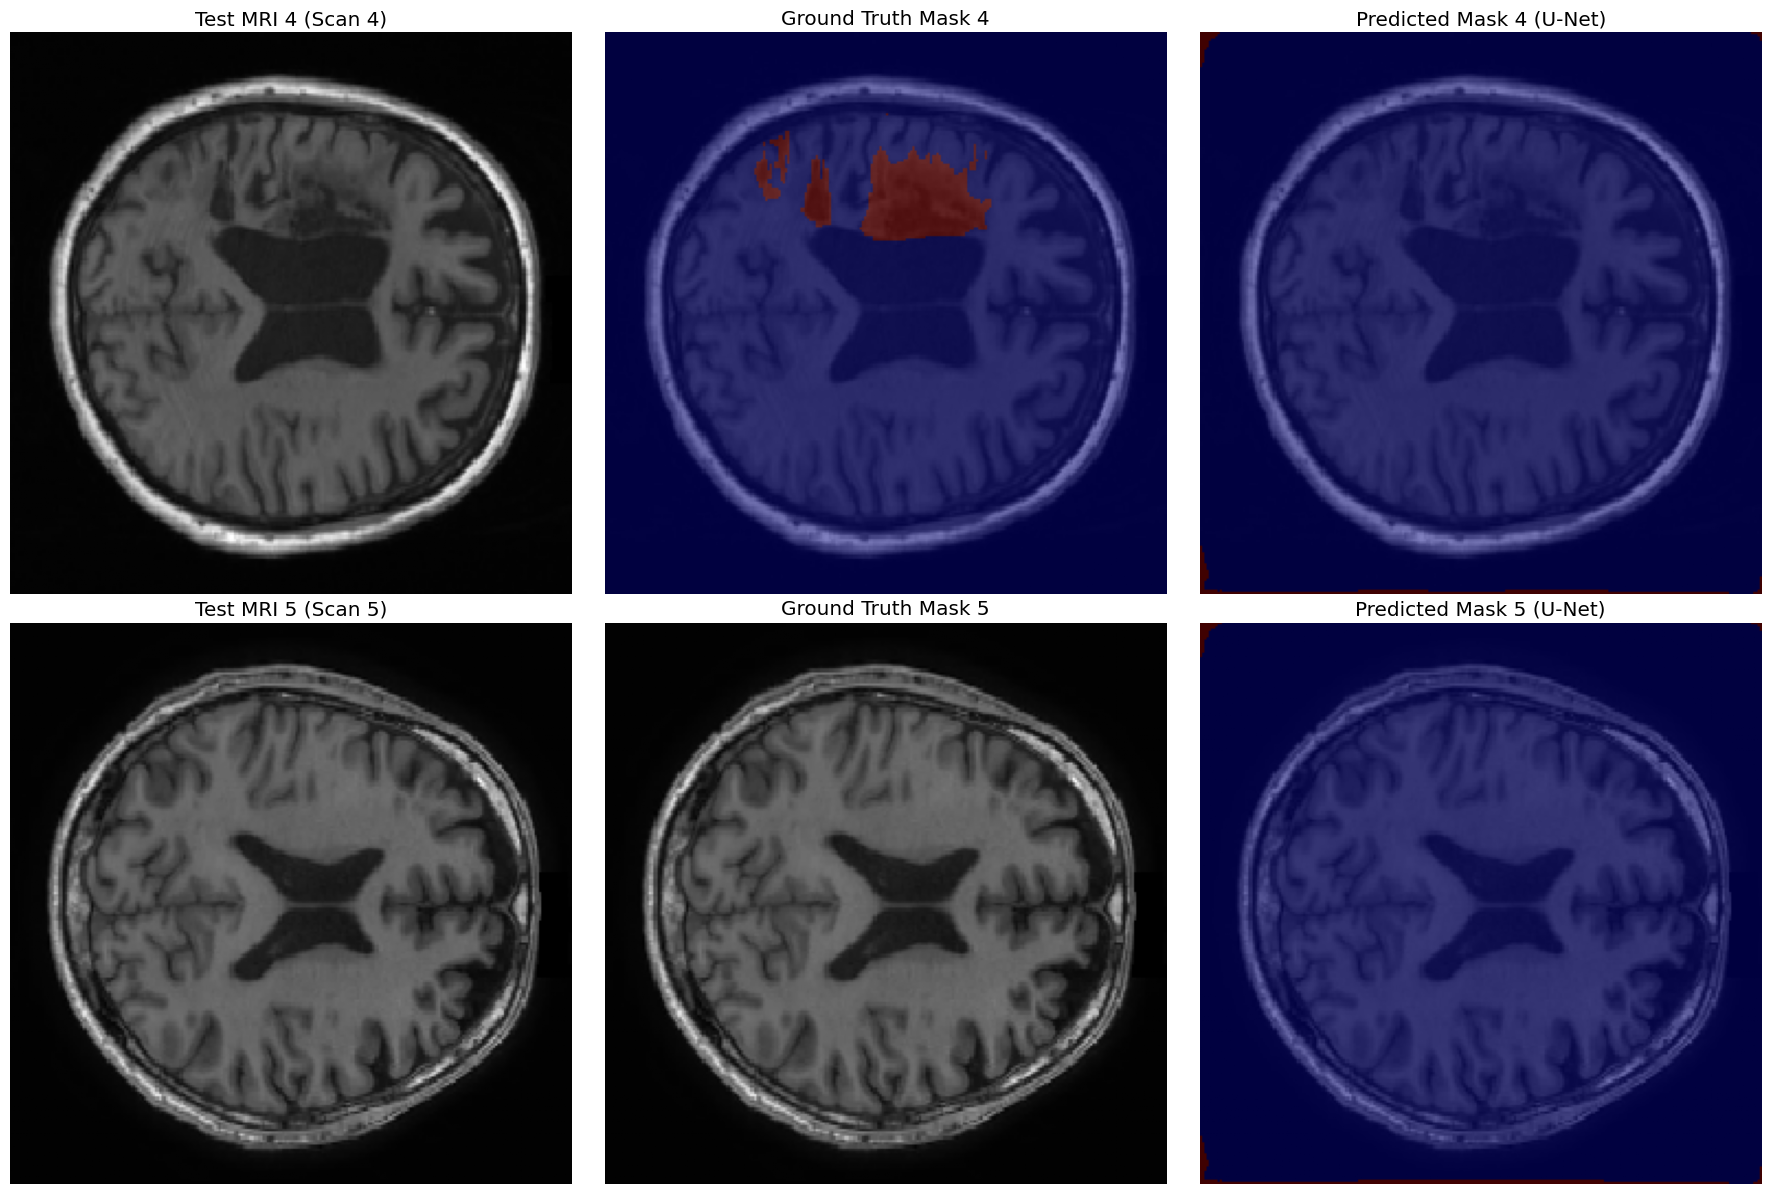

In [47]:
# Predict lesion masks for test images
predicted_masks = unet.predict(test_images)

# Apply threshold to binarize predicted masks
threshold = 0.2
predicted_masks_bin = (predicted_masks > threshold).astype(np.uint8)

# Display predictions for both test cases
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i in range(2):
    # MRI Scan
    axes[i, 0].imshow(test_images[i, :, :, 0], cmap="gray")
    axes[i, 0].set_title(f"Test MRI {i+4} (Scan {i+4})")
    axes[i, 0].axis("off")

    # Ground Truth Mask
    axes[i, 1].imshow(test_images[i, :, :, 0], cmap="gray")
    axes[i, 1].imshow(test_masks[i, :, :, 0], cmap="jet", alpha=0.5)
    axes[i, 1].set_title(f"Ground Truth Mask {i+4}")
    axes[i, 1].axis("off")

    # Predicted Mask
    axes[i, 2].imshow(test_images[i, :, :, 0], cmap="gray")
    axes[i, 2].imshow(predicted_masks_bin[i, :, :, 0], cmap="jet", alpha=0.5)
    axes[i, 2].set_title(f"Predicted Mask {i+4} (U-Net)")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

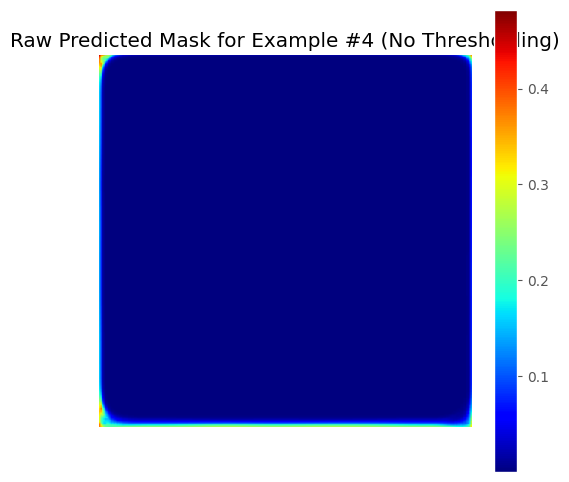

In [49]:
plt.figure(figsize=(6,6))
plt.imshow(predicted_masks[0, :, :, 0], cmap="jet")
plt.colorbar()
plt.title("Raw Predicted Mask for Example #4 (No Thresholding)")
plt.axis("off")
plt.show()

The model isn't predicting correctly - it's likely overfitted, given the small amount of training data. Let's augment the training data.

In [50]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [56]:
# Data augmentation settings
data_gen_args = dict(rotation_range=15,
                     width_shift_range=0.1,
                     height_shift_range=0.1,
                     shear_range=0.05,
                     zoom_range=0.1,
                     horizontal_flip=True,
                     fill_mode='nearest')

# Create ImageDataGenerator instances
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)

# Generate augmented data
train_image_generator = image_datagen.flow(train_images, batch_size=1, seed=42)
train_mask_generator = mask_datagen.flow(train_masks, batch_size=1, seed=42)

# Convert generators to TensorFlow Dataset
train_dataset = tf.data.Dataset.zip((
    tf.data.Dataset.from_generator(lambda: train_image_generator, output_signature=tf.TensorSpec(shape=(1, 256, 256, 1), dtype=tf.float32)),
    tf.data.Dataset.from_generator(lambda: train_mask_generator, output_signature=tf.TensorSpec(shape=(1, 256, 256, 1), dtype=tf.float32))
))
# Prefetch for better performance
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

In [58]:
# Train the U-Net model using the dataset
history = unet.fit(train_dataset, epochs=30, steps_per_epoch=len(train_images))

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 26s 8s/step - accuracy: 0.9594 - loss: 0.4061
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.9675 - loss: 0.3783
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.9581 - loss: 0.3019
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.9644 - loss: 0.3706
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.9581 - loss: 0.2998
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.9478 - loss: 0.3660
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.9668 - loss: 0.3199
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 8s/step - accuracy: 0.9536 - loss: 0.3098
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.9633 - loss: 0.2928
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.9731 - loss: 0.3243
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.9604 - loss: 0.2488
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.9628 - loss: 0.2849
Epoch 13/30
3

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


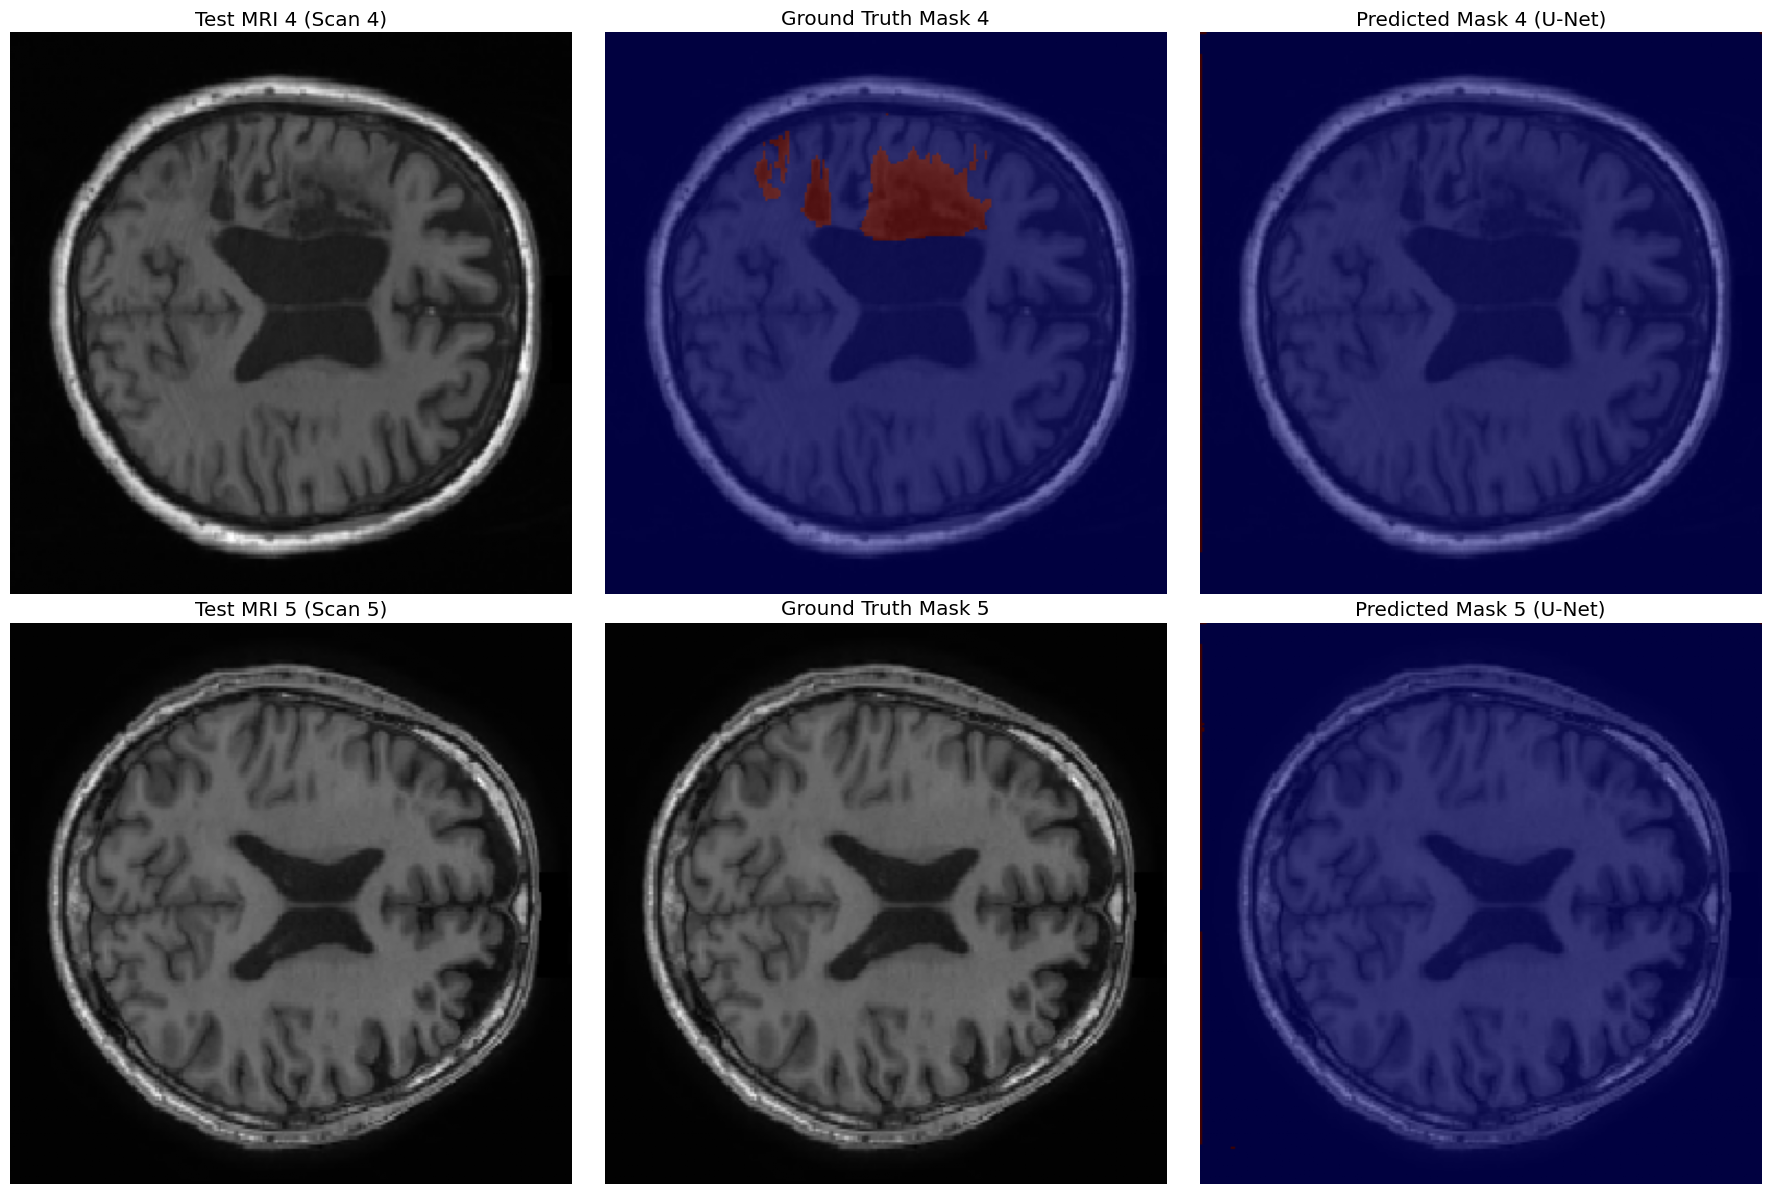

In [59]:
# Predict lesion masks for test images
predicted_masks = unet.predict(test_images)

# Apply threshold to binarize predicted masks
threshold = 0.2
predicted_masks_bin = (predicted_masks > threshold).astype(np.uint8)

# Display predictions for both test cases
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i in range(2):
    # MRI Scan
    axes[i, 0].imshow(test_images[i, :, :, 0], cmap="gray")
    axes[i, 0].set_title(f"Test MRI {i+4} (Scan {i+4})")
    axes[i, 0].axis("off")

    # Ground Truth Mask
    axes[i, 1].imshow(test_images[i, :, :, 0], cmap="gray")
    axes[i, 1].imshow(test_masks[i, :, :, 0], cmap="jet", alpha=0.5)
    axes[i, 1].set_title(f"Ground Truth Mask {i+4}")
    axes[i, 1].axis("off")

    # Predicted Mask
    axes[i, 2].imshow(test_images[i, :, :, 0], cmap="gray")
    axes[i, 2].imshow(predicted_masks_bin[i, :, :, 0], cmap="jet", alpha=0.5)
    axes[i, 2].set_title(f"Predicted Mask {i+4} (U-Net)")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

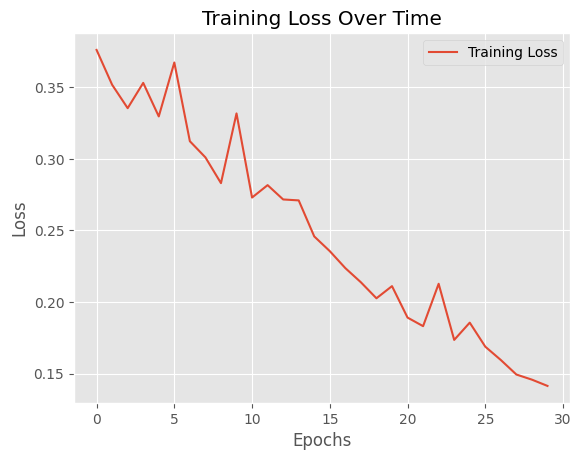

In [60]:
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.show()

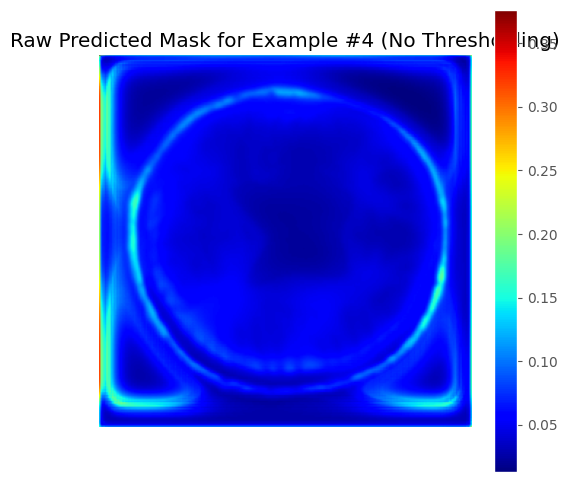

In [61]:
plt.figure(figsize=(6,6))
plt.imshow(predicted_masks[0, :, :, 0], cmap="jet")
plt.colorbar()
plt.title("Raw Predicted Mask for Example #4 (No Thresholding)")
plt.axis("off")
plt.show()

Now it appears that the model is overfitting to the background of the data. To fix this I have a few things to try, like
1. Switch to Dice Loss and retrain.
2. Train for 50 epochs instead of 30.
3. Apply stronger data augmentation for better generalization.
4. Lower the threshold to 0.05 and re-check the mask.

In [66]:
import tensorflow.keras.backend as K

In [67]:
# --- Step 1: Define Dice Loss ---
def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Recompile U-Net with Dice Loss
unet.compile(optimizer='adam', loss=dice_loss, metrics=['accuracy'])

In [68]:
# --- Step 2: Apply Stronger Data Augmentation ---
data_gen_args = dict(rotation_range=30,  # More aggressive rotations
                     width_shift_range=0.3,  # More translation
                     height_shift_range=0.3,
                     shear_range=0.2,  # Increase shear
                     zoom_range=0.3,  # More zoom
                     brightness_range=[0.7, 1.3],  # Wider brightness variation
                     horizontal_flip=True,
                     vertical_flip=True,  # Allow vertical flips too
                     fill_mode='nearest')

# Create ImageDataGenerator instances
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)

# Generate augmented data
train_image_generator = image_datagen.flow(train_images, batch_size=1, seed=42)
train_mask_generator = mask_datagen.flow(train_masks, batch_size=1, seed=42)

# Convert generators to TensorFlow Dataset
train_dataset = tf.data.Dataset.zip((
    tf.data.Dataset.from_generator(lambda: train_image_generator, output_signature=tf.TensorSpec(shape=(1, 256, 256, 1), dtype=tf.float32)),
    tf.data.Dataset.from_generator(lambda: train_mask_generator, output_signature=tf.TensorSpec(shape=(1, 256, 256, 1), dtype=tf.float32))
))

# Prefetch for better performance
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

In [69]:
# --- Step 3: Train U-Net for More Epochs (50 instead of 30) ---
history = unet.fit(train_dataset, epochs=50, steps_per_epoch=len(train_images))

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 61s 7s/step - accuracy: 0.8354 - loss: 0.9769
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step - accuracy: 0.5121 - loss: 0.9496
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.5927 - loss: 0.9948
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 8s/step - accuracy: 0.4729 - loss: 1.0000
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.4803 - loss: 0.9947
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.4826 - loss: 0.9865
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.4710 - loss: 1.0000
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.4984 - loss: 0.8973
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.4723 - loss: 0.9414
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.4571 - loss: 0.9609
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.4976 - loss: 0.8303
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 7s/step - accuracy: 0.4783 - loss: 0.9740
Epoch 13/50
3

In [72]:
# --- Step 4: Predict on Test Images ---
predicted_masks = unet.predict(test_images)

# Apply lower threshold to binarize predicted masks
threshold = 0.05  # Lower threshold to capture more potential lesion pixels
predicted_masks_bin = (predicted_masks > threshold).astype(np.uint8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


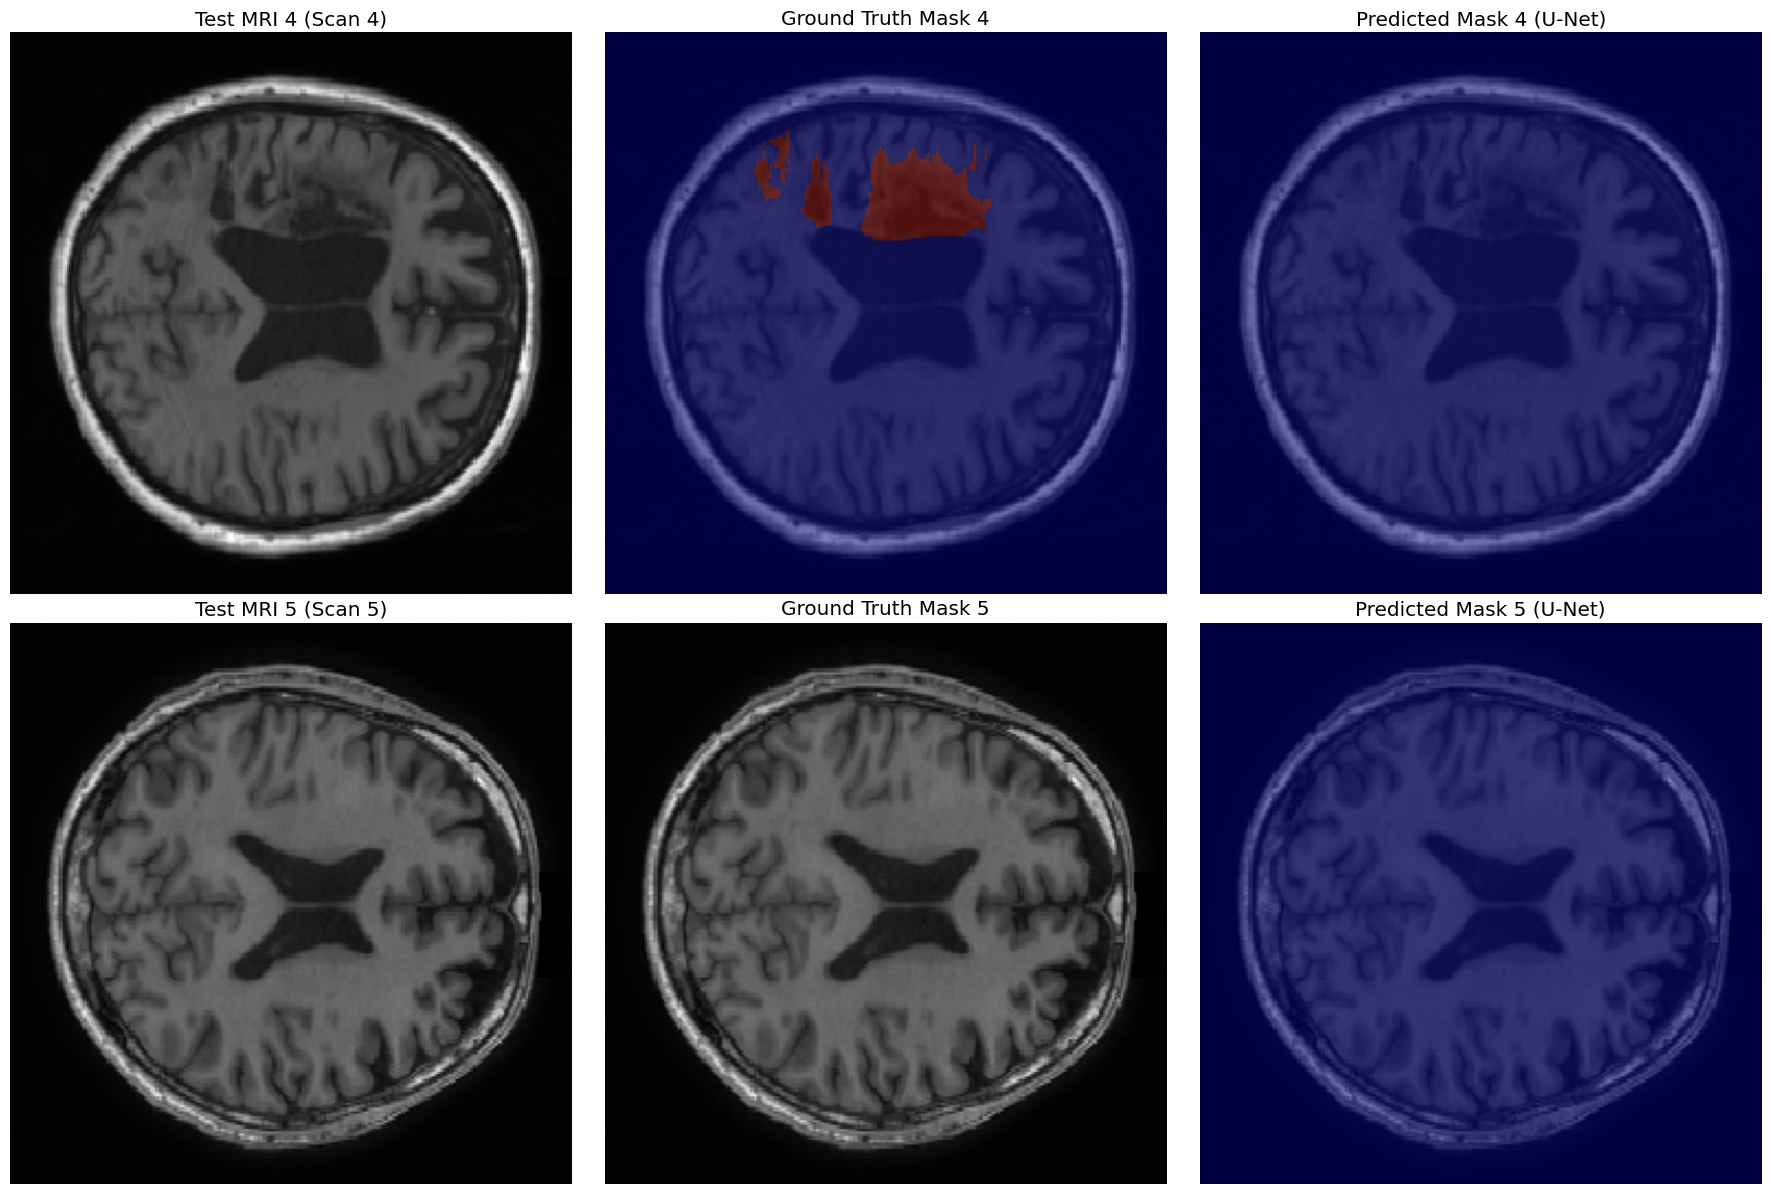

In [73]:
# --- Step 5: Display Predictions for Test Cases ---
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i in range(2):
    # MRI Scan
    axes[i, 0].imshow(test_images[i, :, :, 0], cmap="gray")
    axes[i, 0].set_title(f"Test MRI {i+4} (Scan {i+4})")
    axes[i, 0].axis("off")

    # Ground Truth Mask
    axes[i, 1].imshow(test_images[i, :, :, 0], cmap="gray")
    axes[i, 1].imshow(test_masks[i, :, :, 0], cmap="jet", alpha=0.5)
    axes[i, 1].set_title(f"Ground Truth Mask {i+4}")
    axes[i, 1].axis("off")

    # Predicted Mask
    axes[i, 2].imshow(test_images[i, :, :, 0], cmap="gray")
    axes[i, 2].imshow(predicted_masks_bin[i, :, :, 0], cmap="jet", alpha=0.5)
    axes[i, 2].set_title(f"Predicted Mask {i+4} (U-Net)")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

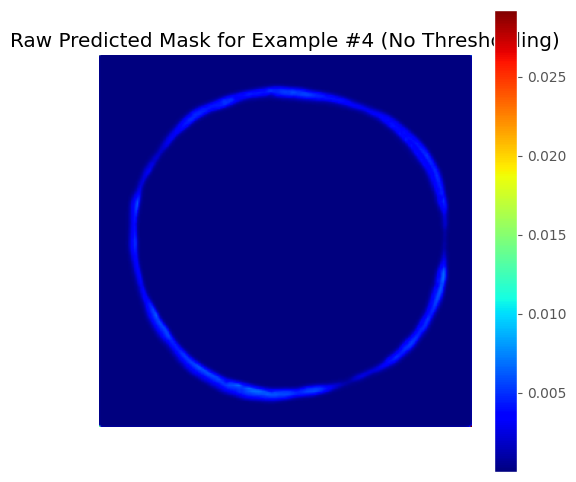

In [74]:
# --- Step 6: Visualize Raw Predicted Mask for Example #4 ---
plt.figure(figsize=(6,6))
plt.imshow(predicted_masks[0, :, :, 0], cmap="jet")
plt.colorbar()
plt.title("Raw Predicted Mask for Example #4 (No Thresholding)")
plt.axis("off")
plt.show()

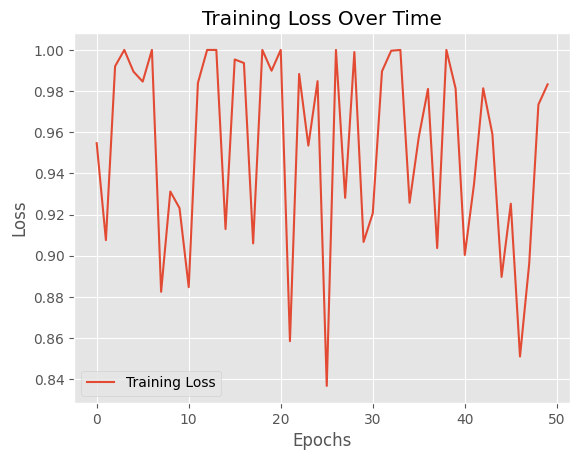

In [75]:
# --- Step 7: Plot Training Loss to Monitor Overfitting ---
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.legend()
plt.show()

Hoo boy that's much worse! I'm probably over-complicating it. I will need to take a step back and restart from the beginning, I think. I am not going to bother calculating error at the moment, becasue my model is not really generating a prediction.

Overall, I think the biggest hurdle is that I definitely need more training data, 5 examples is far too small to get a good model. I was hoping I could get something started on the smaller set, and then apply it to a larger data set, but I can see this data set is simply far too small.

Overall though, this was a good first dive into U-Net. We do hope to find a pre-trained model to use for our project, but this was a good dive into how U-Net works and the different parameters we can play around with.